# Discrete-Time Signals

This notebook covers discrete-time signals (unit impulse, unit step, real and complex exponential sequences, periodic sequences)

## 1. Discrete-Time Signals

**A note on notation**

When plotting discrete-time signals, the horizontal axis is often drawn as a continuous line, but $x[n]$ is actually 
**defined only for integer values of $n$**.

### Unit Impulse Sequence

$$\delta[n] = \begin{cases} 0, & n \neq 0 \\ 1, & n = 0 \end{cases}$$

Defined for $n$ ranging from $-\infty$ to $+\infty$. It poses no problems of definition or realizability.

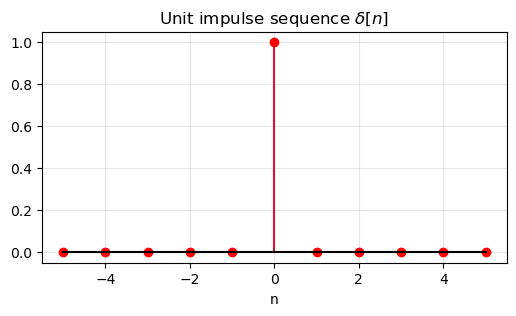

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-5, 6)
delta = (n == 0).astype(float)

plt.figure(figsize=(6,3))
plt.stem(n, delta, linefmt='crimson', markerfmt='ro', basefmt='black')
plt.title(r'Unit impulse sequence $\delta[n]$')
plt.xlabel('n')
plt.grid(alpha=0.3)
plt.show()

### Delayed (Shifted) Impulse

**Shift** is a property of all sequences: it represents a translation in time of a signal.

$$A\,\delta[n-k] = \begin{cases} 0, & n \neq k \\ A, & n = k \end{cases}$$

A delayed impulse is equivalent to the unit impulse shifted by $k$ and scaled by $A$.

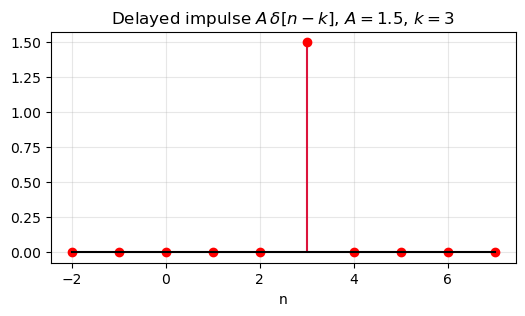

In [2]:
A, k = 1.5, 3
n = np.arange(-2, 8)
shifted = A * (n == k).astype(float)

plt.figure(figsize=(6,3))
plt.stem(n, shifted, linefmt='crimson', markerfmt='ro', basefmt='black')
plt.title(r'Delayed impulse $A\,\delta[n-k]$, $A=1.5$, $k=3$')
plt.xlabel('n')
plt.grid(alpha=0.3)
plt.show()

### Sampling Property

Any sequence $x[n]$ can be expressed as a sum of impulses with appropriate amplitude:

$$x[n] = \sum_{k=-\infty}^{+\infty} x[k] \cdot \delta[n-k]$$

where each term contributes an *impulse amplitude* $x[k]$ at a *shifted position* $k$.

To make this concrete, the cell below first isolates the nonzero terms of $x[n]$, draws each one as its own weighted, 
shifted impulse, then accumulates them one at a time so you can watch the running sum converge to the original sequence.

In [3]:
x = np.array([0, 0, 1, 3, 2, 4, 0, 0])
n = np.arange(len(x)) - 2   # n = [-2, -1, 0, 1, 2, 3, 4, 5]

# Keep only the nonzero terms -- these are the only impulses that actually contribute
nonzero = [(k, xk) for k, xk in zip(n, x) if xk != 0]
print('Nonzero terms x[k]*delta[n-k]:', nonzero)

Nonzero terms x[k]*delta[n-k]: [(0, 1), (1, 3), (2, 2), (3, 4)]


**Step 1 — each nonzero sample is one weighted, shifted impulse.** Every term in the sum $x[n]=\sum_k x[k]\,\delta[n-k]$ is just a spike of height $x[k]$ sitting at position $k$.

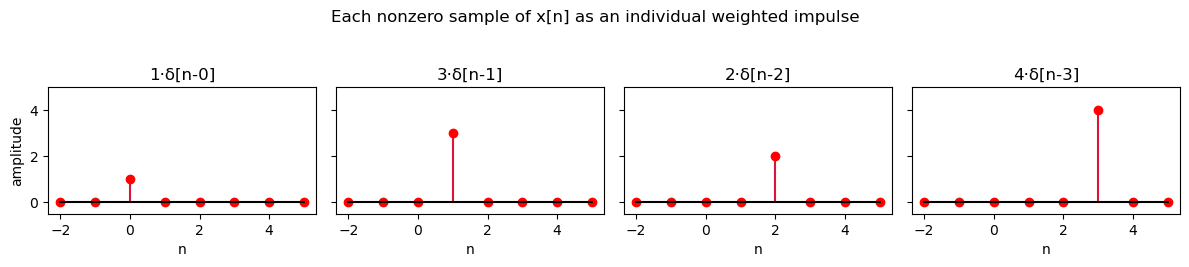

In [4]:
fig, axes = plt.subplots(1, len(nonzero), figsize=(3*len(nonzero), 2.5), sharey=True)

for ax, (k, xk) in zip(axes, nonzero):
    term = xk * (n == k).astype(float)
    ax.stem(n, term, linefmt='crimson', markerfmt='ro', basefmt='black')
    ax.set_title(f'{xk}·δ[n-{k}]' if k >= 0 else f'{xk}·δ[n+{-k}]')
    ax.set_xlabel('n')
    ax.set_ylim(-0.5, 5)

axes[0].set_ylabel('amplitude')
plt.suptitle('Each nonzero sample of x[n] as an individual weighted impulse', y=1.05)
plt.tight_layout()
plt.show()

**Step 2 — accumulate the impulses one at a time.** After all of them have been added, the running sum should look exactly like the original sequence.

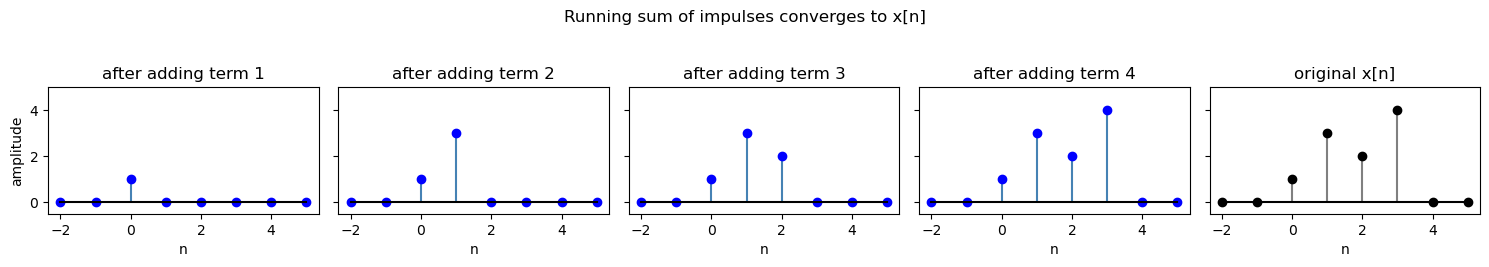

Reconstruction matches original: True


In [5]:
running_sum = np.zeros_like(x, dtype=float)
fig, axes = plt.subplots(1, len(nonzero) + 1, figsize=(3*(len(nonzero)+1), 2.5), sharey=True)

for i, (ax, (k, xk)) in enumerate(zip(axes, nonzero)):
    term = xk * (n == k).astype(float)
    running_sum = running_sum + term
    ax.stem(n, running_sum, linefmt='steelblue', markerfmt='bo', basefmt='black')
    ax.set_title(f'after adding term {i+1}')
    ax.set_xlabel('n')
    ax.set_ylim(-0.5, 5)

axes[-1].stem(n, x, linefmt='gray', markerfmt='ko', basefmt='black')
axes[-1].set_title('original x[n]')
axes[-1].set_xlabel('n')

axes[0].set_ylabel('amplitude')
plt.suptitle('Running sum of impulses converges to x[n]', y=1.05)
plt.tight_layout()
plt.show()

print('Reconstruction matches original:', np.allclose(running_sum, x))

**Step 3 — side-by-side final comparison.** The original sequence and the sequence rebuilt purely from a sum of scaled, shifted impulses are identical — exactly what the sampling property guarantees.

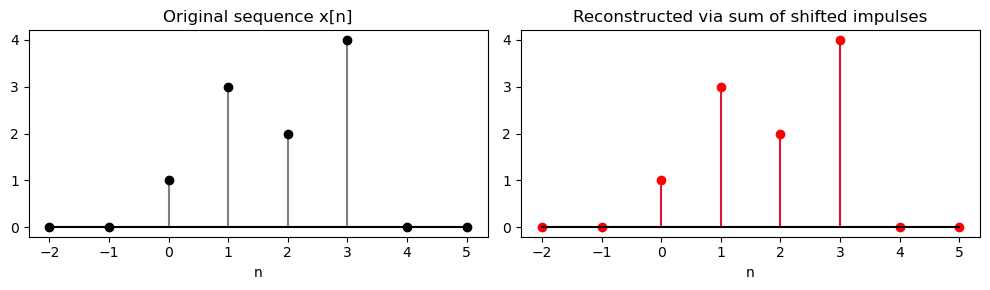

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,3))

axes[0].stem(n, x, linefmt='gray', markerfmt='ko', basefmt='black')
axes[0].set_title('Original sequence x[n]')
axes[0].set_xlabel('n')

axes[1].stem(n, running_sum, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[1].set_title('Reconstructed via sum of shifted impulses')
axes[1].set_xlabel('n')

plt.tight_layout()
plt.show()

### Unit Step Sequence

$$u[n] = \begin{cases} 0, & n < 0 \\ 1, & n \geq 0 \end{cases}$$

Using the sampling property:

$$u[n] = \sum_{k=0}^{+\infty} \delta[n-k]$$

It is also easy to verify that:
- the **step** is the running **sum** of the impulse: $\;u[n] = \sum_{k=-\infty}^{n} \delta[k]$
- the **impulse** is the (first) **difference** of the step: $\;\delta[n] = u[n] - u[n-1]$

In general, just as in the continuous-time case, a family of sequences can be defined through the operations of summation and finite difference.

**Example — unit ramp**

$$r[n] = \sum_{k=-\infty}^{n} u[k] \qquad u[n] = r[n] - r[n-1]$$

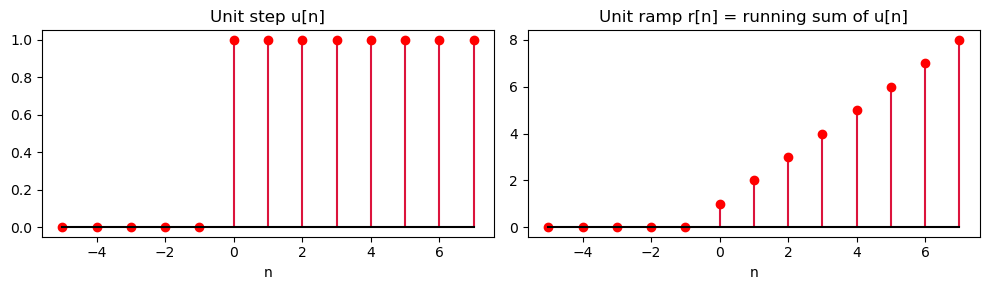

In [7]:
n = np.arange(-5, 8)
u = (n >= 0).astype(float)
r = np.array([np.sum(u[:i+1]) for i in range(len(n))])  # running sum -> ramp

fig, axes = plt.subplots(1, 2, figsize=(10,3))
axes[0].stem(n, u, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[0].set_title('Unit step u[n]')
axes[0].set_xlabel('n')

axes[1].stem(n, r, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[1].set_title('Unit ramp r[n] = running sum of u[n]')
axes[1].set_xlabel('n')
plt.tight_layout()
plt.show()

### Real Exponential Sequences

$$x[n] = A\,\alpha^{n}, \qquad A, \alpha \in \mathbb{R}$$

These play a key role in the study of linear systems. Depending on $\alpha$, several cases arise:

| Range of $\alpha$ | Amplitude | Sign |
|---|---|---|
| $0 < \alpha < 1$ | decreasing | positive |
| $-1 < \alpha < 0$ | decreasing | alternating |
| $\alpha = 1$ | constant | positive |
| $\alpha = -1$ | constant | alternating |
| $\alpha > 1$ | increasing | positive |
| $\alpha < -1$ | increasing | alternating |

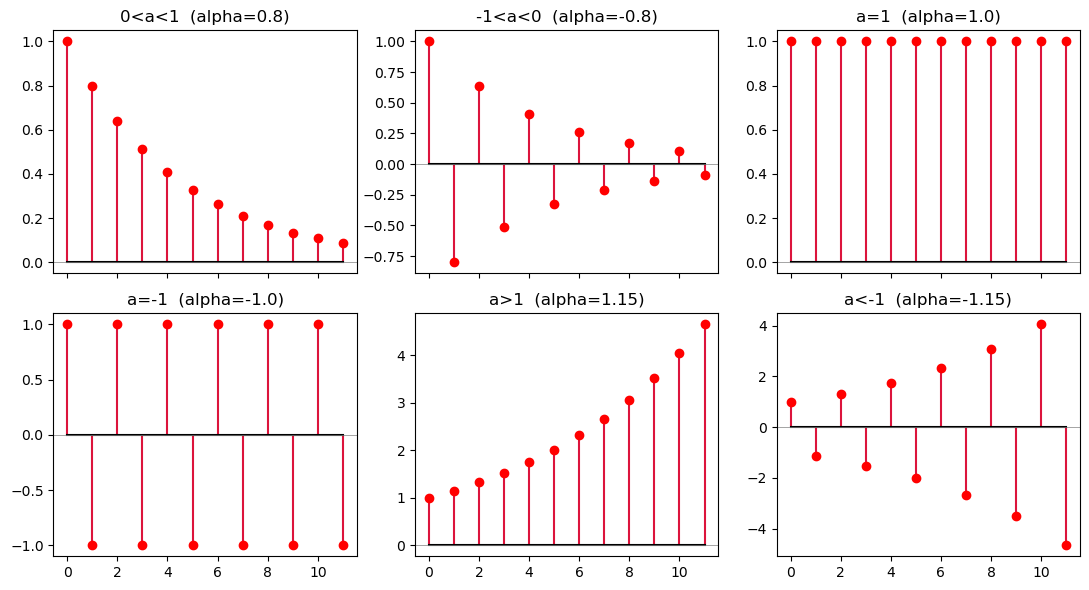

In [8]:
n = np.arange(0, 12)
alphas = [0.8, -0.8, 1.0, -1.0, 1.15, -1.15]
labels = ['0<a<1', '-1<a<0', 'a=1', 'a=-1', 'a>1', 'a<-1']

fig, axes = plt.subplots(2, 3, figsize=(11,6), sharex=True)
for ax, a, lab in zip(axes.flat, alphas, labels):
    x = a ** n
    ax.stem(n, x, linefmt='crimson', markerfmt='ro', basefmt='black')
    ax.set_title(f'{lab}  (alpha={a})')
    ax.axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

### Complex Exponential Sequences

$$x[n] = A \cdot \alpha^{n}, \qquad A, \alpha \in \mathbb{C}$$

Writing $A = |A|e^{j\phi}$ and $\alpha = |\alpha|e^{j\omega}$:

$$x[n] = |A||\alpha|^{n} \cdot e^{j(\omega n + \phi)} = |A||\alpha|^{n}\cos(\omega n+\phi) + j\,|A||\alpha|^{n}\sin(\omega n+\phi)$$

These play a key role in the study of linear systems. The **envelope** of the sequence behaves like the real exponential, depending on $|\alpha|$:

| $|\alpha|$ | Envelope behavior |
|---|---|
| $< 1$ | decreasing with $n$ |
| $= 1$ | constant |
| $> 1$ | increasing with $n$ |

**Special cases**
- Pure complex exponential: $|A|e^{j(\omega n + \phi)}$
- Real cosine: $\cos(\omega n + \phi) = \dfrac{e^{j(\omega n+\phi)} + e^{-j(\omega n+\phi)}}{2}$
- Real sine: $\sin(\omega n + \phi) = \dfrac{e^{j(\omega n+\phi)} - e^{-j(\omega n+\phi)}}{2j}$

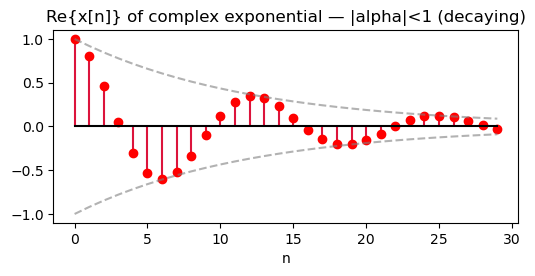

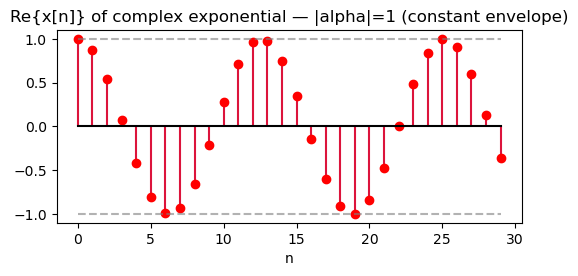

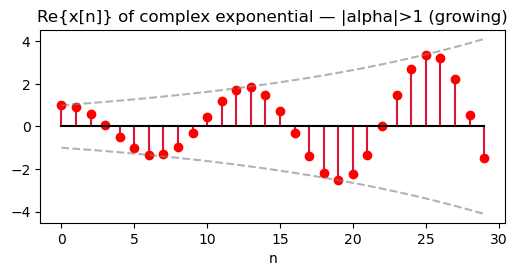

In [9]:
n = np.arange(0, 30)
omega, phi = 0.5, 0
A = 1.0

for alpha_mag, label in [(0.92, '|alpha|<1 (decaying)'), (1.0, '|alpha|=1 (constant envelope)'), (1.05, '|alpha|>1 (growing)')]:
    x = A * alpha_mag**n * np.exp(1j*(omega*n + phi))
    plt.figure(figsize=(6,2.5))
    plt.stem(n, x.real, linefmt='crimson', markerfmt='ro', basefmt='black')
    plt.plot(n, A*alpha_mag**n, 'gray', linestyle='--', alpha=0.6)
    plt.plot(n, -A*alpha_mag**n, 'gray', linestyle='--', alpha=0.6)
    plt.title(f'Re{{x[n]}} of complex exponential — {label}')
    plt.xlabel('n')
    plt.show()

### Periodic Sequences

$$x[n] = x[n+N] \qquad \forall n, \quad N = \text{period (integer)}$$

The sequence repeats after $N$ samples. For complex exponentials $e^{j(\omega n + \phi)}$:
- $\omega$ = angular frequency (rad/sample)
- $f = \dfrac{\omega}{2\pi}$ = frequency
- $\phi$ = initial phase

#### Property 1 — $2\pi$-periodicity in frequency

A sequence with frequency $(\omega_0 + 2\pi)$ is identical to one with frequency $\omega_0$.

**Proof.**

$$Ae^{j(\omega_0 n + 2\pi n + \phi)} = Ae^{j(\omega_0 n+\phi)}\cdot e^{j2\pi n} = Ae^{j(\omega_0 n+\phi)}$$

since $e^{j2\pi n} = \cos(2\pi n) + j\sin(2\pi n) = 1 + j0 = 1\ \ \forall n$.

Hence $\omega_0 + 2\pi \equiv \omega_0$, which means there are no "infinite" distinct frequencies: it is sufficient to consider $0 \le \omega_0 \le 2\pi$ (or equivalently $-\pi \le \omega \le \pi$, i.e. $0 \le f \le 1$ or $-0.5 \le f \le 0.5$).

Sinusoidal or complex exponential sequences obtained by varying $\omega_0$ in any interval $2\pi k \le \omega_0 \le 2\pi(k+1)$ (for any integer $k$) are completely identical to those obtained by varying $\omega_0$ in $0 \le \omega_0 \le 2\pi$.

#### Property 2 — "high" vs. "low" frequencies

"High" frequencies cluster around $\pm\pi$; "low" frequencies cluster around $0$ and $2\pi$.

**Proof.**

$$e^{j[(2\pi-\omega_0)n+\phi]} = e^{j2\pi n}\cdot e^{j(-\omega_0 n+\phi)} = e^{j(-\omega_0 n+\phi)}$$

- $\omega_0 \to 0 \Rightarrow -\omega_0 n$ is a small quantity (low frequency)
- $\omega_0 \to \pi \Rightarrow -\omega_0 n$ is a large quantity (high frequency)

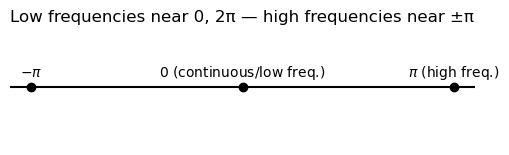

In [10]:
fig, ax = plt.subplots(figsize=(6,1.5))
ax.axhline(0, color='black')
ax.annotate('', xy=(np.pi, 0), xytext=(-np.pi, 0), arrowprops=dict(arrowstyle='-'))
ax.plot([-np.pi, 0, np.pi], [0,0,0], 'ko')
ax.text(-np.pi, 0.1, r'$-\pi$', ha='center')
ax.text(0, 0.1, r'$0$ (continuous/low freq.)', ha='center')
ax.text(np.pi, 0.1, r'$\pi$ (high freq.)', ha='center')
ax.set_ylim(-0.5, 0.5)
ax.axis('off')
plt.title('Low frequencies near 0, 2π — high frequencies near ±π')
plt.show()

#### Property 3 — Not every complex exponential is periodic

**Proof.** For periodicity we need:

$$e^{j[\omega_0(n+N)+\phi]} = e^{j(\omega_0 n+\phi)} \;\Longrightarrow\; \omega_0 N = 2\pi k$$

$$\frac{\omega_0}{2\pi} = \frac{k}{N} \quad \text{must be rational, with } k \text{ integer and } N \text{ the period}$$

If such an integer $N$ exists, the sequence is periodic with period $N$.

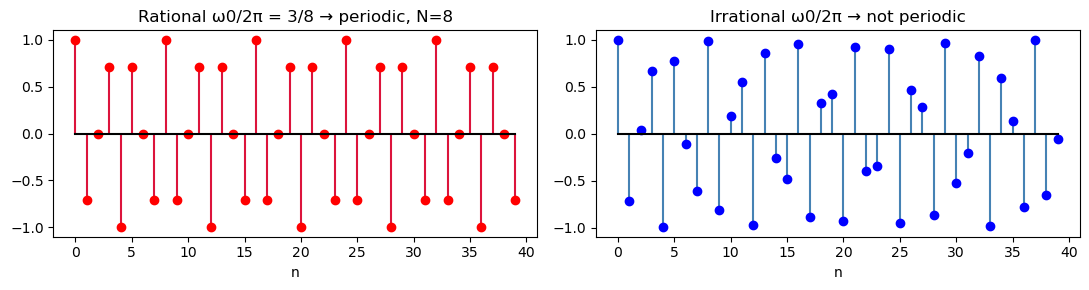

In [11]:
# Example: omega0/2pi rational -> periodic, vs irrational -> not periodic
n = np.arange(0, 40)

fig, axes = plt.subplots(1, 2, figsize=(11,3))

omega0 = 2*np.pi * (3/8)  # rational ratio k/N = 3/8 -> periodic with N=8
x = np.cos(omega0*n)
axes[0].stem(n, x, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[0].set_title('Rational ω0/2π = 3/8 → periodic, N=8')
axes[0].set_xlabel('n')

omega0_irr = 2*np.pi * (1/np.sqrt(7))  # irrational ratio -> not periodic
x_irr = np.cos(omega0_irr*n)
axes[1].stem(n, x_irr, linefmt='steelblue', markerfmt='bo', basefmt='black')
axes[1].set_title('Irrational ω0/2π → not periodic')
axes[1].set_xlabel('n')
plt.tight_layout()
plt.show()

## Summary

| | Definition | Key property |
|---|---|---|
| Unit impulse $\delta[n]$ | 1 at $n=0$, else 0 | basis for the sampling property |
| Unit step $u[n]$ | 1 for $n \ge 0$, else 0 | running sum of $\delta[n]$ |
| Real exponential | $A\alpha^n$ | shape set by sign/magnitude of $\alpha$ |
| Complex exponential | $A\alpha^n$, $A,\alpha \in \mathbb{C}$ | envelope set by $|\alpha|$ |
| Periodic sequence | $x[n]=x[n+N]$ | periodic in $\omega$ with period $2\pi$ |